### Read the data of TEFF, logg, and FeH from all the fits files in the R10000FITS folder
output file is **fits_parameters.csv**

In [4]:
import os
from astropy.io import fits
import pandas as pd

In [ ]:
# Define relative path
base_path = r"../R10000FITS"

# Specify target folders
target_folders = ['Z-1.0', 'Z-2.0', 'Z-3.0', 'Z-4.0']

# Create a list to store results
results = []

# Only traverse specified folders
for folder in target_folders:
    folder_path = os.path.join(base_path, folder)
    if os.path.exists(folder_path):
        # Traverse all fits files in the folder
        for fits_file in os.listdir(folder_path):
            if fits_file.endswith('.fits'):
                file_path = os.path.join(folder_path, fits_file)
                
                with fits.open(file_path) as hdu:
                    # Get parameters from header
                    header = hdu[0].header
                    teff = header['PHXTEFF']
                    logg = header['PHXLOGG']
                    feh = header['PHXM_H']
                    
                    # Add results to list
                    results.append({
                        'folder': folder,
                        'filename': fits_file,
                        'Teff': teff,
                        'log g': logg,
                        '[Fe/H]': feh
                    })

# Convert results to DataFrame and save
df = pd.DataFrame(results)
df.to_csv('fits_parameters.csv', index=False)

# Print statistics
print(f"Total processed files: {len(results)}")
print("\nNumber of files in each folder:")
print(df['folder'].value_counts())

Total processed files: 3370

Number of files in each folder:
folder
Z-2.0    848
Z-3.0    848
Z-1.0    846
Z-4.0    828
Name: count, dtype: int64


### Read the fits file information from fits_parameters.csv and plot it

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

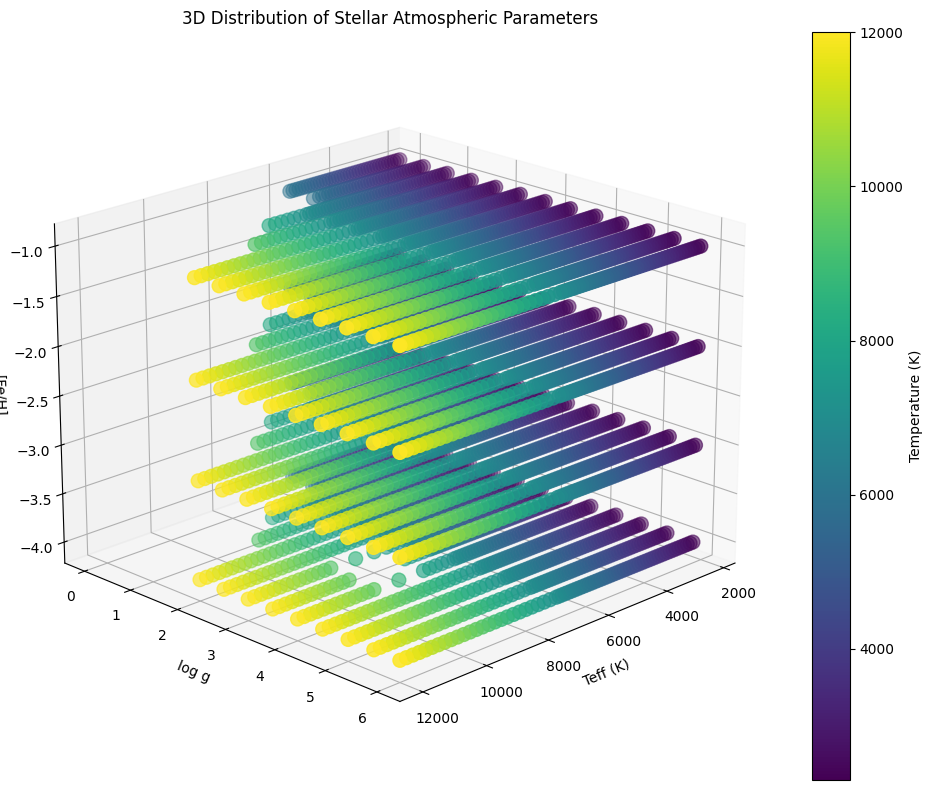


Parameter Ranges:
Temperature Range: 2300K - 12000K
log g Range: 0.00 - 6.00
[Fe/H] Range: -4.00 - -1.00


In [ ]:
# Read CSV file
df = pd.read_csv('fits_parameters.csv')

# Create 3D figure
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Draw scatter plot
scatter = ax.scatter(df['Teff'], 
                    df['log g'], 
                    df['[Fe/H]'],
                    c=df['Teff'],  # Use temperature for color mapping
                    cmap='viridis',
                    s=100)  # Point size

# Set axis labels
ax.set_xlabel('Teff (K)')
ax.set_ylabel('log g')
ax.set_zlabel('[Fe/H]')

# Add title
plt.title('3D Distribution of Stellar Atmospheric Parameters')

# Add colorbar
plt.colorbar(scatter, label='Temperature (K)')

# Adjust view angle
ax.view_init(elev=20, azim=45)

# Show figure
plt.tight_layout()
plt.show()

# Print parameter ranges
print("\nParameter Ranges:")
print(f"Temperature Range: {df['Teff'].min():.0f}K - {df['Teff'].max():.0f}K")
print(f"log g Range: {df['log g'].min():.2f} - {df['log g'].max():.2f}")
print(f"[Fe/H] Range: {df['[Fe/H]'].min():.2f} - {df['[Fe/H]'].max():.2f}")

### Obtain the distribution intervals and range of the sample points

In [7]:
import pandas as pd
import numpy as np

In [8]:
# Read CSV file
df = pd.read_csv('fits_parameters.csv')

def analyze_parameter_intervals(values, parameter_name):
    """Analyze parameter interval patterns"""
    # Get unique values and sort
    unique_vals = sorted(values.unique())
    
    # Calculate differences between adjacent values
    intervals = np.diff(unique_vals)
    
    # Find different intervals and their corresponding ranges
    current_interval = intervals[0]
    start_value = unique_vals[0]
    
    print(f"\nInterval analysis for {parameter_name}:")
    print("-" * 50)
    
    for i, (val, interval) in enumerate(zip(unique_vals[1:], intervals)):
        if i < len(intervals)-1 and intervals[i+1] != current_interval:
            print(f"Range [{start_value:.1f}, {val:.1f}] has interval: {current_interval:.1f}")
            start_value = val
            current_interval = intervals[i+1]
        elif i == len(intervals)-1:
            print(f"Range [{start_value:.1f}, {val:.1f}] has interval: {current_interval:.1f}")

# Analyze each parameter
analyze_parameter_intervals(df['Teff'], 'Teff')
analyze_parameter_intervals(df['log g'], 'log g')
analyze_parameter_intervals(df['[Fe/H]'], '[Fe/H]')

# Output parameter ranges
print("\nParameter ranges:")
print("-" * 50)
for param in ['Teff', 'log g', '[Fe/H]']:
    min_val = df[param].min()
    max_val = df[param].max()
    print(f"{param}: [{min_val:.1f}, {max_val:.1f}]")


Interval analysis for Teff:
--------------------------------------------------
Range [2300.0, 7000.0] has interval: 100.0
Range [7000.0, 12000.0] has interval: 200.0

Interval analysis for log g:
--------------------------------------------------
Range [0.0, 6.0] has interval: 0.5

Interval analysis for [Fe/H]:
--------------------------------------------------
Range [-4.0, -1.0] has interval: 1.0

Parameter ranges:
--------------------------------------------------
Teff: [2300.0, 12000.0]
log g: [0.0, 6.0]
[Fe/H]: [-4.0, -1.0]


### Impute the missing TEFF sample data points

In [18]:
import pandas as pd
import numpy as np

# 读取fits参数文件
df = pd.read_csv('fits_parameters.csv')

# 找出所有唯一的log g和[Fe/H]组合
param_combinations = df[['log g', '[Fe/H]']].drop_duplicates()

# 创建用于存储间隔的列表
gaps = []

# 对每个参数组合进行分析
for _, row in param_combinations.iterrows():
    log_g = row['log g']
    fe_h = row['[Fe/H]']
    
    # 获取当前参数组合下的所有Teff值
    teff_values = df[(df['log g'] == log_g) & (df['[Fe/H]'] == fe_h)]['Teff'].sort_values()
    
    # 计算相邻Teff值之间的差值
    teff_diffs = np.diff(teff_values)
    
    # 找出大于200的间隔
    large_gaps_idx = np.where(teff_diffs > 200)[0]
    
    # 记录间隔信息
    for idx in large_gaps_idx:
        gaps.append({
            'log_g': log_g,
            'Fe_H': fe_h,
            'lower_teff': teff_values.iloc[idx],
            'upper_teff': teff_values.iloc[idx + 1],
            'gap': teff_values.iloc[idx + 1] - teff_values.iloc[idx]
        })

# 创建间隔数据框并保存
gaps_df = pd.DataFrame(gaps)
gaps_df.to_csv('teff_gaps.csv', index=False)

print("分析完成，结果已保存到teff_gaps.csv")

分析完成，结果已保存到teff_gaps.csv


### Linear interpolation to generate intermediate spectra data for TEFF

In [10]:
import numpy as np
from astropy.io import fits
import os
from typing import Union, List
import warnings

In [17]:
def generate_intermediate_spectra(
    teff: Union[List[float], float],
    logg: Union[List[float], float],
    feh: Union[List[float], float],
    scale_factor: float
) -> None:
    """
    Function to generate intermediate spectral sample points
    
    Parameters:
    teff: TEFF value or list of TEFF values
    logg: log g value or list of log g values
    feh: [Fe/H] value or list of [Fe/H] values
    scale_factor: Division scale (must be decimal)
    """
    
    # Convert input to numpy arrays
    teff = np.array([teff]) if isinstance(teff, (int, float)) else np.array(teff)
    logg = np.array([logg]) if isinstance(logg, (int, float)) else np.array(logg)
    feh = np.array([feh]) if isinstance(feh, (int, float)) else np.array(feh)
    
    # Base path
    base_path = r"../R10000FITS"
    
    # Process each parameter combination
    for f in feh:
        folder = f"Z{f:+.1f}"
        folder_path = os.path.join(base_path, folder)
        
        for g in logg:
            for t_idx in range(len(teff)-1):
                t1, t2 = teff[t_idx], teff[t_idx+1]
                
                # Read original fits files
                file1 = f"lte{int(t1):05d}-{g:.2f}{f:+.1f}.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits"
                file2 = f"lte{int(t2):05d}-{g:.2f}{f:+.1f}.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits"
                
                with fits.open(os.path.join(folder_path, file1)) as hdul1, \
                     fits.open(os.path.join(folder_path, file2)) as hdul2:
                    data1 = hdul1[0].data
                    data2 = hdul2[0].data
                    
                    # Calculate interpolation points
                    step = (t2 - t1) * scale_factor
                    intermediate_teffs = np.arange(t1 + step, t2, step)
                    
                    # Interpolate for each intermediate point
                    for new_teff in intermediate_teffs:
                        # Linear interpolation
                        weight2 = (new_teff - t1) / (t2 - t1)
                        weight1 = 1 - weight2
                        new_data = weight1 * data1 + weight2 * data2
                        
                        # Create new header
                        new_hdr = fits.Header()
                        new_hdr['PHXTEFF'] = new_teff
                        new_hdr['PHXLOGG'] = g
                        new_hdr['PHXM_H'] = f
                        
                        # Save new fits file
                        new_filename = f"lte{int(new_teff):05d}-{g:.2f}{f:+.1f}.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits"
                        new_path = os.path.join(folder_path, new_filename)
                        
                        # Create and save new fits file
                        hdu = fits.PrimaryHDU(data=new_data, header=new_hdr)
                        hdu.writeto(new_path, overwrite=True)
                        
                        print(f"已生成文件: {new_filename}")

# 读取间隔数据
gaps_df = pd.read_csv('teff_gaps.csv')

# 逐行处理数据
for idx, row in gaps_df.iterrows():
    # 获取当前行的参数
    log_g = row['log_g']
    fe_h = row['Fe_H']
    lower_teff = row['lower_teff']
    upper_teff = row['upper_teff']
    gap = row['gap']
    
    # 计算scale_factor
    scale_factor = 200 / gap
    
    # 设置温度点
    temps = [lower_teff, upper_teff]
    
    # 生成中间光谱
    teff = temps          # TEFF range
    logg = log_g         # log g value from file
    feh = fe_h           # Fe/H value from file
    print(f"teff = {teff}, logg = {logg}, feh = {feh}")
    generate_intermediate_spectra(teff, logg, feh, scale_factor)

teff = [7600.0, 8000.0], logg = 3.0, feh = -4.0
已生成文件: lte07800-3.00-4.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
teff = [8000.0, 8600.0], logg = 3.0, feh = -4.0
已生成文件: lte08200-3.00-4.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
已生成文件: lte08400-3.00-4.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
teff = [8600.0, 9400.0], logg = 3.0, feh = -4.0
已生成文件: lte08800-3.00-4.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
已生成文件: lte09000-3.00-4.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
已生成文件: lte09200-3.00-4.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits


### Reread the data of TEFF, logg, and FeH from all the fits files in the R10000FITS folder
output file is **fits_parameters.csv**

In [19]:
import os
from astropy.io import fits
import pandas as pd

# Define relative path
base_path = r"../R10000FITS"

# Specify target folders
target_folders = ['Z-1.0', 'Z-2.0', 'Z-3.0', 'Z-4.0']

# Create a list to store results
results = []

# Only traverse specified folders
for folder in target_folders:
    folder_path = os.path.join(base_path, folder)
    if os.path.exists(folder_path):
        # Traverse all fits files in the folder
        for fits_file in os.listdir(folder_path):
            if fits_file.endswith('.fits'):
                file_path = os.path.join(folder_path, fits_file)
                
                with fits.open(file_path) as hdu:
                    # Get parameters from header
                    header = hdu[0].header
                    teff = header['PHXTEFF']
                    logg = header['PHXLOGG']
                    feh = header['PHXM_H']
                    
                    # Add results to list
                    results.append({
                        'folder': folder,
                        'filename': fits_file,
                        'Teff': teff,
                        'log g': logg,
                        '[Fe/H]': feh
                    })

# Convert results to DataFrame and save
df = pd.DataFrame(results)
df.to_csv('fits_parameters_addMissingTEFF.csv', index=False)

# Print statistics
print(f"Total processed files: {len(results)}")
print("\nNumber of files in each folder:")
print(df['folder'].value_counts())

Total processed files: 3390

Number of files in each folder:
folder
Z-2.0    848
Z-3.0    848
Z-4.0    848
Z-1.0    846
Name: count, dtype: int64


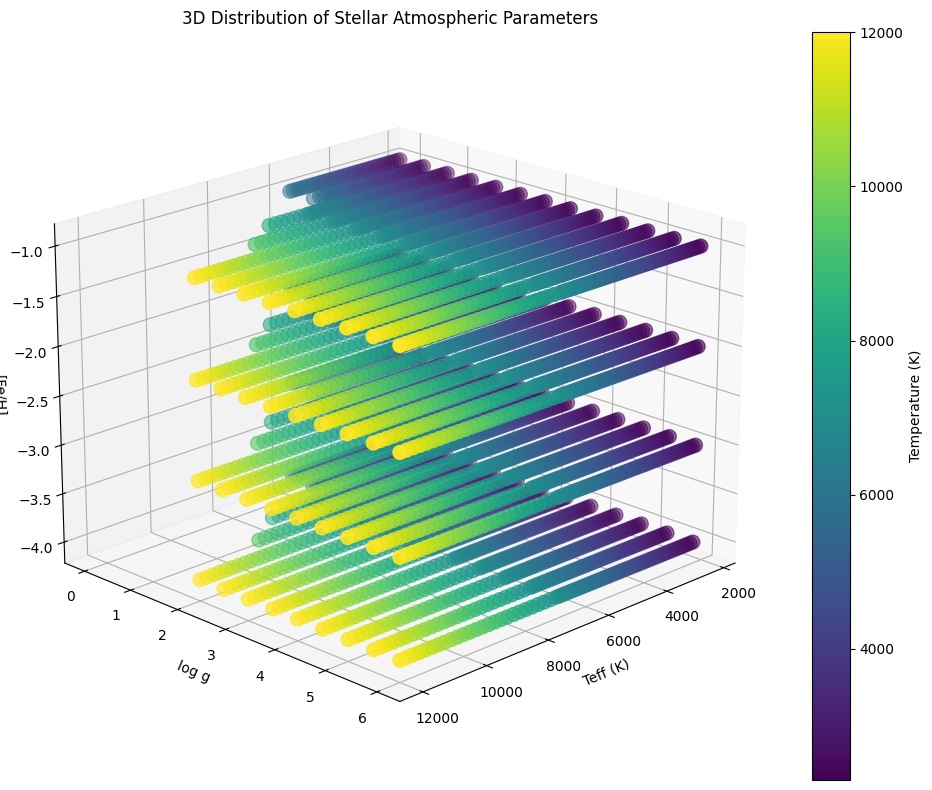


Parameter Ranges:
Temperature Range: 2300K - 12000K
log g Range: 0.00 - 6.00
[Fe/H] Range: -4.00 - -1.00


In [20]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Read CSV file
df = pd.read_csv('fits_parameters_addMissingTEFF.csv')

# Create 3D figure
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Draw scatter plot
scatter = ax.scatter(df['Teff'], 
                    df['log g'], 
                    df['[Fe/H]'],
                    c=df['Teff'],  # Use temperature for color mapping
                    cmap='viridis',
                    s=100)  # Point size

# Set axis labels
ax.set_xlabel('Teff (K)')
ax.set_ylabel('log g')
ax.set_zlabel('[Fe/H]')

# Add title
plt.title('3D Distribution of Stellar Atmospheric Parameters')

# Add colorbar
plt.colorbar(scatter, label='Temperature (K)')

# Adjust view angle
ax.view_init(elev=20, azim=45)

# Show figure
plt.tight_layout()
plt.show()

# Print parameter ranges
print("\nParameter Ranges:")
print(f"Temperature Range: {df['Teff'].min():.0f}K - {df['Teff'].max():.0f}K")
print(f"log g Range: {df['log g'].min():.2f} - {df['log g'].max():.2f}")
print(f"[Fe/H] Range: {df['[Fe/H]'].min():.2f} - {df['[Fe/H]'].max():.2f}")

### Obtain the cuboid constructed by the sample points.

In [21]:
import numpy as np
import pandas as pd
from itertools import product

def find_adjacent_points():
    # Read data
    df = pd.read_csv('fits_parameters_addMissingTEFF.csv')
    
    # Get unique values for each parameter and sort
    teff_values = sorted(df['Teff'].unique())
    logg_values = sorted(df['log g'].unique())
    feh_values = sorted(df['[Fe/H]'].unique())
    
    # Create list to store cube information
    cubes = []
    
    # Iterate through Teff, logg, and feh values
    for i in range(len(teff_values)-1):
        for j in range(len(logg_values)-1):
            for k in range(len(feh_values)-1):
                # Get coordinates of current cube's 8 vertices
                current_cube = []
                for teff, logg, feh in product([teff_values[i], teff_values[i+1]], 
                                             [logg_values[j], logg_values[j+1]], 
                                             [feh_values[k], feh_values[k+1]]):
                    # Check if point exists in dataset
                    if len(df[(df['Teff'] == teff) & 
                            (df['log g'] == logg) & 
                            (df['[Fe/H]'] == feh)]) > 0:
                        current_cube.append((teff, logg, feh))
                
                # Only add to results if all 8 vertices exist
                if len(current_cube) == 8:
                    cubes.append(current_cube)
    
    return cubes

# Get all valid cubes
valid_cubes = find_adjacent_points()

# Save results to CSV
cube_data = []
for cube_idx, cube in enumerate(valid_cubes):
    for point_idx, point in enumerate(cube):
        cube_data.append({
            'cube_id': cube_idx + 1,
            'point_id': point_idx + 1,
            'Teff': point[0],
            'log_g': point[1],
            'Fe_H': point[2]
        })

# Create DataFrame and save to CSV
cube_df = pd.DataFrame(cube_data)
cube_df.to_csv('valid_cubes.csv', index=False)

# Function to read and display cube data
def read_cube_data(csv_file='valid_cubes.csv'):
    df = pd.read_csv(csv_file)
    total_cubes = df['cube_id'].nunique()
    
    print(f"Found {total_cubes} complete cubes")
    print("\nExample cube vertices:")
    
    # Display first cube as example
    first_cube = df[df['cube_id'] == 1]
    for _, point in first_cube.iterrows():
        print(f"Point {int(point['point_id'])}: "
              f"Teff={point['Teff']}, "
              f"log g={point['log_g']}, "
              f"[Fe/H]={point['Fe_H']}")
    
    return df

# Read and display the saved data
cube_data = read_cube_data()

Found 2284 complete cubes

Example cube vertices:
Point 1: Teff=2300.0, log g=0.0, [Fe/H]=-4.0
Point 2: Teff=2300.0, log g=0.0, [Fe/H]=-3.0
Point 3: Teff=2300.0, log g=0.5, [Fe/H]=-4.0
Point 4: Teff=2300.0, log g=0.5, [Fe/H]=-3.0
Point 5: Teff=2400.0, log g=0.0, [Fe/H]=-4.0
Point 6: Teff=2400.0, log g=0.0, [Fe/H]=-3.0
Point 7: Teff=2400.0, log g=0.5, [Fe/H]=-4.0
Point 8: Teff=2400.0, log g=0.5, [Fe/H]=-3.0


### Linear interpolation to generate intermediate spectra data for TEFF, LOGG and Fe/H

In [1]:
import numpy as np
from astropy.io import fits
import os
from typing import Union, List
import warnings
from scipy import interpolate
from pathlib import Path
import gc

In [7]:
def generate_intermediate_points(start: float, end: float, scale_factor: float) -> np.ndarray:
    """生成两个值之间的中间点"""
    step = (end - start) * scale_factor
    return np.arange(start + step, end, step)

def interpolate_3d(teff_points, logg_points, feh_points, teff, logg, feh, base_path):
    """三维线性插值函数"""
    # 找到最近的点的索引
    t_idx = np.searchsorted(teff_points, teff)
    g_idx = np.searchsorted(logg_points, logg)
    f_idx = np.searchsorted(feh_points, feh)
    
    # 确保索引在有效范围内
    t_idx = min(max(t_idx, 1), len(teff_points))
    g_idx = min(max(g_idx, 1), len(logg_points))
    f_idx = min(max(f_idx, 1), len(feh_points))
    
    # 获取周围的点
    t_values = [teff_points[t_idx-1], teff_points[min(t_idx, len(teff_points)-1)]]
    g_values = [logg_points[g_idx-1], logg_points[min(g_idx, len(logg_points)-1)]]
    f_values = [feh_points[f_idx-1], feh_points[min(f_idx, len(feh_points)-1)]]
    
    # 读取所有周围点的数据
    data_points = []
    for f_val in f_values:
        folder = f"Z{f_val:+.1f}"
        for g_val in g_values:
            for t_val in t_values:
                filename = f"lte{int(t_val):05d}-{g_val:.2f}{f_val:+.1f}.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits"
                filepath = os.path.join(base_path, folder, filename)
                with fits.open(filepath) as hdul:
                    data_points.append(hdul[0].data.copy())
    
    # 构建插值点的坐标
    points = np.array([(t, g, f) for f in f_values for g in g_values for t in t_values])
    values = np.array(data_points)
    
    # 执行三维线性插值
    interpolator = interpolate.LinearNDInterpolator(points, values)
    result = interpolator(np.array([teff, logg, feh]))
    
    return result[0]

def generate_intermediate_spectra(
    teff: Union[List[float], float],
    logg: Union[List[float], float],
    feh: Union[List[float], float],
    scale_factor: float
) -> None:
    # 将输入转换为numpy数组并排序
    teff = np.sort(np.array([teff]) if isinstance(teff, (int, float)) else np.array(teff))
    logg = np.sort(np.array([logg]) if isinstance(logg, (int, float)) else np.array(logg))
    feh = np.sort(np.array([feh]) if isinstance(feh, (int, float)) else np.array(feh))
    
    # 基础路径
    base_path = r"../R10000FITS"
    
    # 在主循环开始前强制进行垃圾回收
    gc.collect()
    
    try:
        # 对每个Fe/H区间进行处理，包括最后一个点
        for f_idx in range(len(feh)):
            # 处理非边界点
            if f_idx < len(feh) - 1:
                f1, f2 = feh[f_idx], feh[f_idx+1]
                intermediate_fehs = np.append([f1], generate_intermediate_points(f1, f2, scale_factor))
            else:
                # 处理最后一个点
                intermediate_fehs = [feh[f_idx]]
            
            for f in intermediate_fehs:
                folder = f"Z{f:+.1f}"
                folder_path = os.path.join(base_path, folder)
                
                # 对每个log g区间进行处理，包括最后一个点
                for g_idx in range(len(logg)):
                    # 处理非边界点
                    if g_idx < len(logg) - 1:
                        g1, g2 = logg[g_idx], logg[g_idx+1]
                        intermediate_loggs = np.append([g1], generate_intermediate_points(g1, g2, scale_factor))
                    else:
                        # 处理最后一个点
                        intermediate_loggs = [logg[g_idx]]
                    
                    for g in intermediate_loggs:
                        # 对每个TEFF区间进行处理，包括最后一个点
                        for t_idx in range(len(teff)):
                            # 处理非边界点
                            if t_idx < len(teff) - 1:
                                t1, t2 = teff[t_idx], teff[t_idx+1]
                                intermediate_teffs = np.append([t1], generate_intermediate_points(t1, t2, scale_factor))
                            else:
                                # 处理最后一个点
                                intermediate_teffs = [teff[t_idx]]
                            
                            for new_teff in intermediate_teffs:
                                try:
                                    # 创建新的header
                                    new_hdr = fits.Header()
                                    new_hdr['PHXTEFF'] = new_teff
                                    new_hdr['PHXLOGG'] = g
                                    new_hdr['PHXM_H'] = f
                                    
                                    # 如果是原始点，从文件读取数据
                                    if new_teff in teff and g in logg and f in feh:
                                        filename = f"lte{int(new_teff):05d}-{g:.2f}{f:+.1f}.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits"
                                        with fits.open(os.path.join(folder_path, filename)) as hdul:
                                            new_data = hdul[0].data.copy()
                                    else:
                                        # 否则进行三维线性插值
                                        new_data = interpolate_3d(teff, logg, feh, new_teff, g, f, base_path)
                                    
                                    # 保存新的fits文件
                                    new_filename = f"lte{int(new_teff):05d}-{g:.2f}{f:+.1f}.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits"
                                    new_path = os.path.join(folder_path, new_filename)
                                    
                                    # 确保目标文件夹存在
                                    os.makedirs(os.path.dirname(new_path), exist_ok=True)
                                    
                                    # 如果文件存在，先尝试删除
                                    if os.path.exists(new_path):
                                        try:
                                            os.remove(new_path)
                                        except PermissionError:
                                            print(f"警告：无法删除已存在的文件 {new_filename}，可能被其他程序占用")
                                            continue
                                    
                                    # 创建并保存新的fits文件
                                    hdu = fits.PrimaryHDU(data=new_data, header=new_hdr)
                                    hdu.writeto(new_path, overwrite=True)
                                    
                                    print(f"已生成文件: {new_filename}")
                                    
                                except Exception as e:
                                    print(f"处理文件时出错: {str(e)}")
                                    continue
                                
                                finally:
                                    # 确保清理内存
                                    gc.collect()
                    
    except Exception as e:
        print(f"程序执行出错: {str(e)}")
        
    finally:
        # 最后再次进行垃圾回收
        gc.collect()

def read_cube_parameters(csv_file='valid_cubes.csv'):
    # Read the CSV file
    df = pd.read_csv(csv_file)
    
    # Process each cube
    cube_params = []
    for cube_id in df['cube_id'].unique():
        cube_data = df[df['cube_id'] == cube_id]
        
        # Extract unique values for each parameter
        teff_values = sorted(cube_data['Teff'].unique())
        logg_values = sorted(cube_data['log_g'].unique())
        feh_values = sorted(cube_data['Fe_H'].unique())
        
        # Store as a parameter set
        cube_params.append({
            'teff': teff_values[:2],  # Only need min and max
            'logg': logg_values[:2],  # Only need min and max
            'feh': feh_values[:2],    # Only need min and max
        })
    
    return cube_params

# Read and format the cube parameters
cube_params = read_cube_parameters('valid_cubes.csv')

# Print parameters in the desired format
for i, params in enumerate(cube_params):
    teff = params['teff']
    logg = params['logg']
    feh = params['feh']
    scale_factor = 1/10
    generate_intermediate_spectra(teff, logg, feh, scale_factor)

已生成文件: lte02300-0.00-4.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
已生成文件: lte02310-0.00-4.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
已生成文件: lte02320-0.00-4.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
已生成文件: lte02330-0.00-4.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
已生成文件: lte02340-0.00-4.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
已生成文件: lte02350-0.00-4.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
已生成文件: lte02360-0.00-4.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
已生成文件: lte02370-0.00-4.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
已生成文件: lte02380-0.00-4.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
已生成文件: lte02390-0.00-4.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
已生成文件: lte02400-0.00-4.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
已生成文件: lte02300-0.05-4.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
已生成文件: lte02310-0.05-4.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
已生成文件: lte02320-0.05-4.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
已生成文件: lte02330-0.05-4.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
已生成文件: lte02340-0.05-4.0.PHOENIX-ACES-AG

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x152ebf2a2880>>
Traceback (most recent call last):
  File "/home/share/guofangkeda/wangcunshi/.conda/envs/grid_division_fzw/lib/python3.9/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


已生成文件: lte02400-0.20-4.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
已生成文件: lte02300-0.25-4.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
已生成文件: lte02310-0.25-4.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
已生成文件: lte02320-0.25-4.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
已生成文件: lte02330-0.25-4.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
已生成文件: lte02340-0.25-4.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
已生成文件: lte02350-0.25-4.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
已生成文件: lte02360-0.25-4.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
已生成文件: lte02370-0.25-4.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
已生成文件: lte02380-0.25-4.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
已生成文件: lte02390-0.25-4.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
已生成文件: lte02400-0.25-4.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
已生成文件: lte02300-0.30-4.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
已生成文件: lte02310-0.30-4.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
已生成文件: lte02320-0.30-4.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
已生成文件: lte02330-0.30-4.0.PHOENIX-ACES-AG

KeyboardInterrupt: 

### Plot spectra of generated samples and true samples

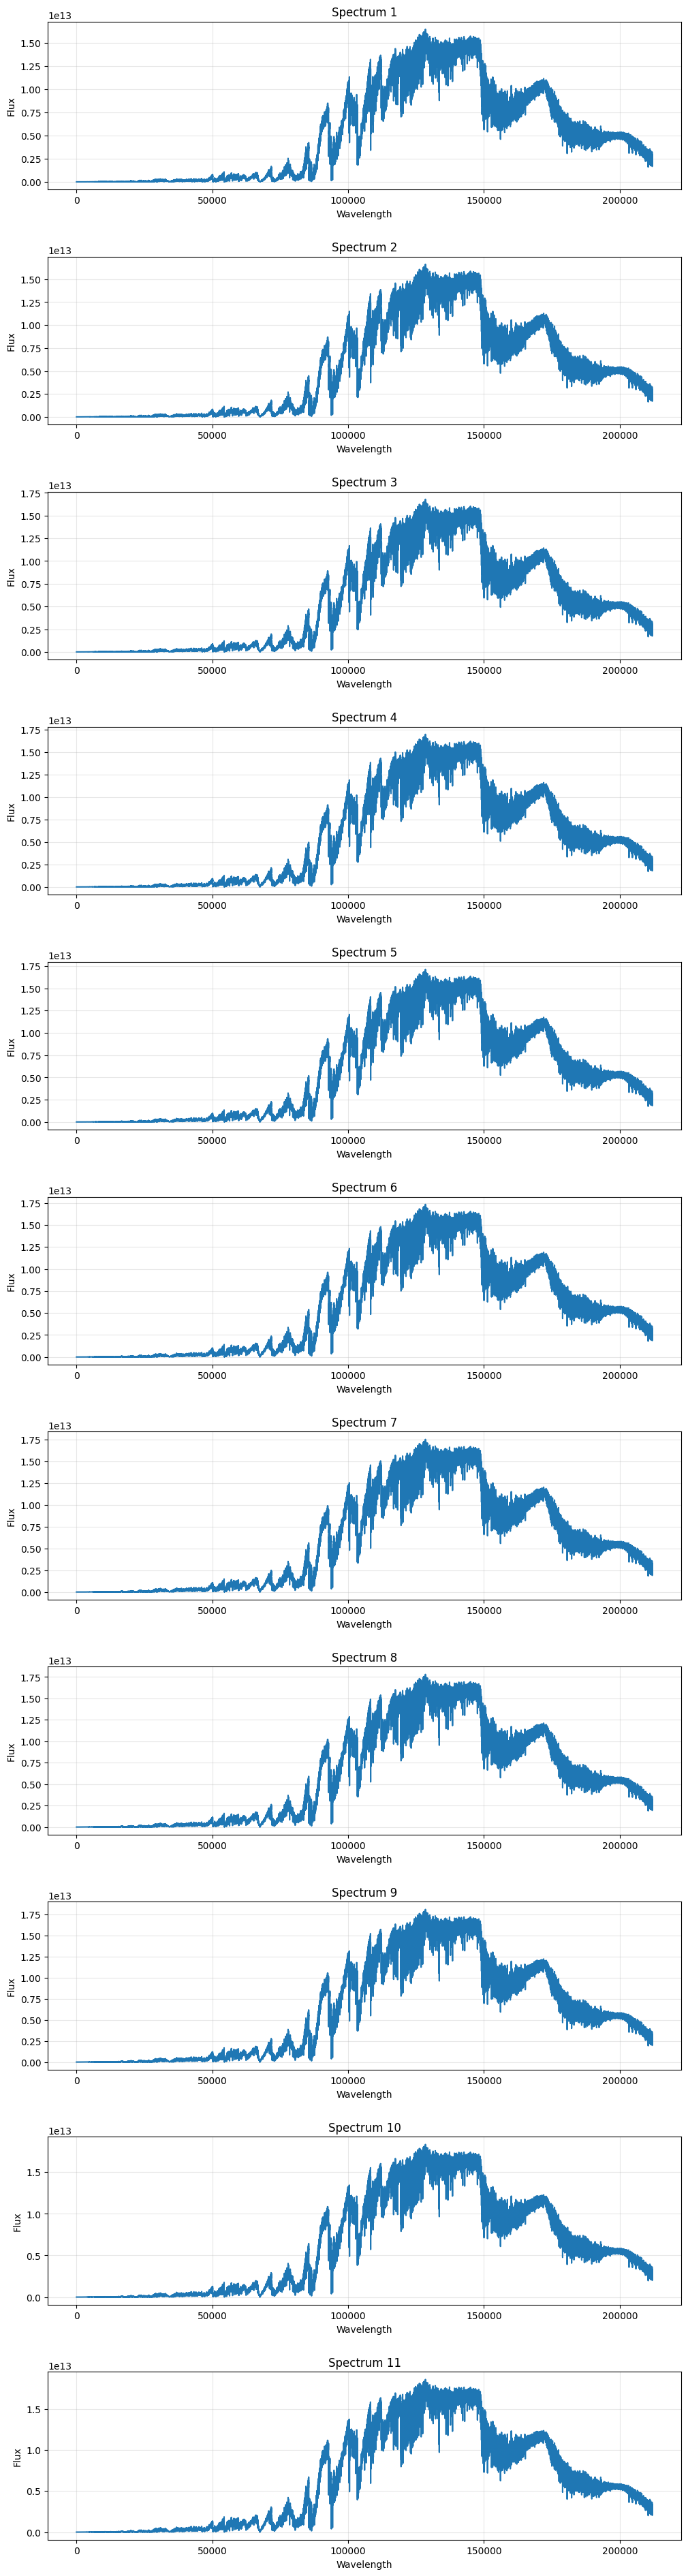

In [ ]:
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt

def plot_fits_subplots(fits_paths):
    # 创建16*1的子图布局
    fig, axes = plt.subplots(11, 1, figsize=(12, 48))
    fig.subplots_adjust(hspace=0.4)  # 调整子图间距
    
    # 遍历每个文件和对应的子图
    for idx, (fits_path, ax) in enumerate(zip(fits_paths, axes)):
        try:
            with fits.open(fits_path) as hdul:
                data = hdul[0].data
                header = hdul[0].header
                
                try:
                    crval1 = header['CRVAL1']
                    cdelt1 = header['CDELT1']
                    wavelength = np.arange(len(data)) * cdelt1 + crval1
                except:
                    wavelength = np.arange(len(data))
                
                # 在子图中绘制数据
                ax.plot(wavelength, data)
                
                # 设置每个子图的标题和标签
                ax.set_title(f'Spectrum {idx+1}')
                ax.set_xlabel('Wavelength')
                ax.set_ylabel('Flux')
                ax.grid(True, alpha=0.3)
                
        except Exception as e:
            ax.text(0.5, 0.5, f'Error loading file {idx+1}: {str(e)}', 
                   ha='center', va='center')
    
    plt.show()

# 使用示例
feh = -1.4
base_path = f"../R10000FITS/Z{feh}/"
# 创建10个文件路径的列表
fits_paths = [
    f"{base_path}lte02400-1.50{feh}.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits",
    f"{base_path}lte02410-1.55{feh}.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits",
    f"{base_path}lte02420-1.60{feh}.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits",
    f"{base_path}lte02430-1.65{feh}.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits",
    f"{base_path}lte02440-1.70{feh}.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits",
    f"{base_path}lte02450-1.75{feh}.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits",
    f"{base_path}lte02460-1.80{feh}.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits",
    f"{base_path}lte02470-1.85{feh}.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits",
    f"{base_path}lte02480-1.90{feh}.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits",
    f"{base_path}lte02490-1.95{feh}.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits",
    f"{base_path}lte02500-2.00{feh}.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits",
]

plot_fits_subplots(fits_paths)